# Capitulo 1 - Datos financieros con Python

Este notebook descarga precios financieros desde Yahoo Finance mediante `yfinance`, calcula retornos logaritmicos y exporta datos, tablas y figuras reproducibles.

La fuente es util para docencia y prototipos. Para investigacion formal se debe documentar proveedor, fecha de descarga, tickers, periodo y limitaciones.

In [1]:
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf


def find_book_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "PROJECT_BRIEF.md").exists() and candidate.name == "econometria_financiera_python":
            return candidate
    raise FileNotFoundError("No se encontro la raiz del libro econometria_financiera_python.")


BOOK_ROOT = find_book_root(Path.cwd().resolve())
DATA_PROCESSED = BOOK_ROOT / "data" / "processed"
OUTPUT_TABLES = BOOK_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = BOOK_ROOT / "outputs" / "figures"
OUTPUT_REPORTS = BOOK_ROOT / "outputs" / "reports"

for folder in [DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_FIGURES, OUTPUT_REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Libro: {BOOK_ROOT.name}")

Libro: econometria_financiera_python


## 1. Parametros de descarga

Usamos tres activos para mostrar diferencias entre mercado amplio, accion individual y criptoactivo. Puede cambiar los tickers para el mini-proyecto.

In [2]:
tickers = ["SPY", "AAPL", "BTC-USD"]
start_date = "2021-01-01"
end_date = None
download_timestamp = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")

prices_raw = yf.download(
    tickers=tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False,
    group_by="column",
)

print(f"Fecha de descarga: {download_timestamp}")
print(f"Filas descargadas: {len(prices_raw):,}")
prices_raw.tail()


1 Failed download:


['AAPL']: OperationalError('database is locked')


Fecha de descarga: 2026-05-06 06:19:48 UTC
Filas descargadas: 1,952


Price      Adj Close                          Close                           \
Ticker          AAPL       BTC-USD        SPY  AAPL       BTC-USD        SPY   
Date                                                                           
2026-05-02       NaN  78657.250000        NaN   NaN  78657.250000        NaN   
2026-05-03       NaN  78538.226562        NaN   NaN  78538.226562        NaN   
2026-05-04       NaN  79827.906250  718.01001   NaN  79827.906250  718.01001   
2026-05-05       NaN           NaN  723.77002   NaN           NaN  723.77002   
2026-05-06       NaN  81237.382812        NaN   NaN  81237.382812        NaN   

Price      High                            Low                          Open  \
Ticker     AAPL       BTC-USD         SPY AAPL       BTC-USD        SPY AAPL   
Date                                                                           
2026-05-02  NaN  79119.789062         NaN  NaN  78031.960938        NaN  NaN   
2026-05-03  NaN  79402.359375         NaN  NaN  78073.078125        NaN  NaN   
2026-05-04  NaN  80742.359375  722.119995  NaN  78217.960938  714.98999  NaN   
2026-05-05  NaN           NaN  725.039978  NaN           NaN  721.48999  NaN   
2026-05-06  NaN  81637.875000         NaN  NaN  80803.703125        NaN  NaN   

Price                                Volume                            
Ticker           BTC-USD         SPY   AAPL       BTC-USD         SPY  
Date                                                                   
2026-05-02  78177.750000         NaN    NaN  1.676153e+10         NaN  
2026-05-03  78656.726562         NaN    NaN  2.054439e+10         NaN  
2026-05-04  78540.289062  720.070007    NaN  5.432509e+10  51950600.0  
2026-05-05           NaN  721.770020    NaN           NaN  36643400.0  
2026-05-06  80900.773438         NaN    NaN  3.867840e+10         NaN

## 2. Seleccion de precio

Usamos `Adj Close` cuando esta disponible porque incorpora ajustes por dividendos y splits. Si una fuente no tiene ese campo, se debe documentar la alternativa.

In [3]:
if isinstance(prices_raw.columns, pd.MultiIndex) and "Adj Close" in prices_raw.columns.get_level_values(0):
    prices = prices_raw["Adj Close"].copy()
    price_field = "Adj Close"
elif isinstance(prices_raw.columns, pd.MultiIndex) and "Close" in prices_raw.columns.get_level_values(0):
    prices = prices_raw["Close"].copy()
    price_field = "Close"
else:
    raise ValueError("No se encontro Adj Close ni Close en la descarga.")

prices = prices.dropna(how="all")
returns_log = np.log(prices / prices.shift(1)).dropna(how="all")
wealth_index = np.exp(returns_log.fillna(0).cumsum())

print(f"Campo usado: {price_field}")
returns_log.describe().T

Campo usado: Adj Close


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BTC-USD,1949.0,0.000513,0.030450,-0.174053,-0.013460,-0.000020,0.014607,0.171821
SPY,1047.0,0.000521,0.010976,-0.060326,-0.004992,0.000556,0.006528,0.099863


## 3. Estadisticas descriptivas

La media y la desviacion estandar diaria son descriptivas. No prueban prediccion ni eficiencia de mercado.

In [4]:
stats = pd.DataFrame({
    "media_diaria": returns_log.mean(),
    "volatilidad_diaria": returns_log.std(),
    "minimo": returns_log.min(),
    "maximo": returns_log.max(),
    "observaciones": returns_log.count(),
})
stats["media_anualizada_aprox"] = stats["media_diaria"] * 252
stats["volatilidad_anualizada_aprox"] = stats["volatilidad_diaria"] * np.sqrt(252)
stats

,media_diaria,volatilidad_diaria,minimo,maximo,observaciones,media_anualizada_aprox,volatilidad_anualizada_aprox
Ticker,,,,,,,
AAPL,NaN,NaN,NaN,NaN,0,NaN,NaN
BTC-USD,0.000513,0.030450,-0.174053,0.171821,1949,0.129266,0.483371
SPY,0.000521,0.010976,-0.060326,0.099863,1047,0.131235,0.174237


## 4. Figura de rendimiento acumulado

Normalizamos cada activo a 1 al inicio de la muestra para comparar crecimiento relativo.

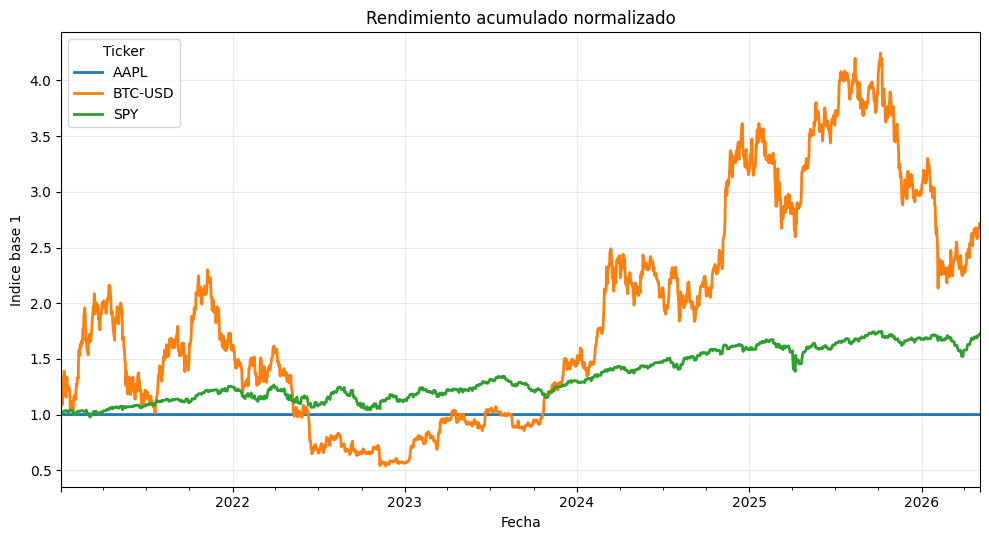

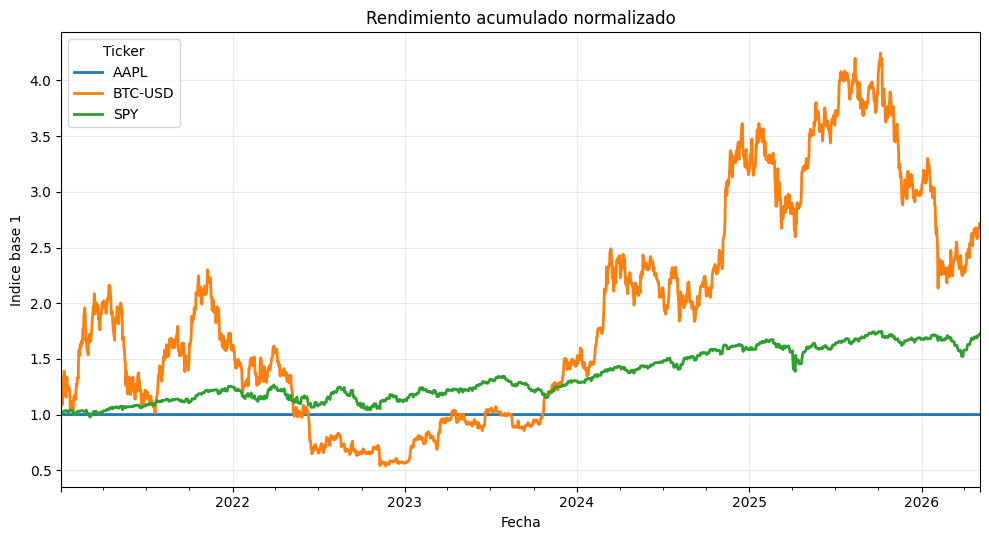

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
wealth_index.plot(ax=ax, linewidth=2)
ax.set_title("Rendimiento acumulado normalizado")
ax.set_ylabel("Indice base 1")
ax.set_xlabel("Fecha")
ax.grid(True, alpha=0.25)
ax.legend(title="Ticker")
fig.tight_layout()
fig

## 5. Exportacion

Exportamos datos procesados, tabla descriptiva, figura y metadata de descarga.

In [6]:
combined = pd.concat(
    {
        "price": prices,
        "log_return": returns_log,
        "wealth_index": wealth_index,
    },
    axis=1,
)

processed_path = DATA_PROCESSED / "chapter_01_precios_y_retornos.csv"
stats_path = OUTPUT_TABLES / "chapter_01_estadisticas_retornos.csv"
figure_path = OUTPUT_FIGURES / "chapter_01_rendimiento_acumulado.png"
metadata_path = OUTPUT_REPORTS / "chapter_01_metadata_descarga.md"

combined.to_csv(processed_path, encoding="utf-8")
stats.to_csv(stats_path, encoding="utf-8")
fig.savefig(figure_path, dpi=160)

metadata = f"""# Metadata de descarga - Capitulo 1

- Fuente: Yahoo Finance via yfinance.
- Tickers: {', '.join(tickers)}.
- Fecha inicial: {start_date}.
- Fecha final: ultima disponible al momento de descarga.
- Fecha de descarga: {download_timestamp}.
- Campo de precio usado: {price_field}.
- Uso recomendado: docencia y prototipos.
- Advertencia: verificar proveedor y terminos de uso para investigacion formal.
"""
metadata_path.write_text(metadata, encoding="utf-8")

print(processed_path.relative_to(BOOK_ROOT))
print(stats_path.relative_to(BOOK_ROOT))
print(figure_path.relative_to(BOOK_ROOT))
print(metadata_path.relative_to(BOOK_ROOT))

data\processed\chapter_01_precios_y_retornos.csv
outputs\tables\chapter_01_estadisticas_retornos.csv
outputs\figures\chapter_01_rendimiento_acumulado.png
outputs\reports\chapter_01_metadata_descarga.md


## 6. Interpretacion prudente

Estos resultados describen una muestra historica descargada en una fecha concreta. No prueban que un activo vaya a rendir mas en el futuro ni que exista una estrategia rentable.